# IEEE Case Study: AI-Driven Smart Energy Audit System

## Abstract
This document presents a professional evaluation of the Smart Energy Audit anomaly detection system under four distinct operational scenarios. The underlying framework utilizes a Dynamic Random Forest for load forecasting and an Isolation Forest for real-time anomaly detection based on power telemetry deltas ($\Delta V$, $\Delta I$, $\Delta P$).

### The 4 Case Studies Analyzed:
1. **Under Voltage:** Supply voltage drops significantly below nominal operational margins (e.g., < 210V).
2. **Normal Grid Supply:** Typical healthy residential supply (230V, nominal load profiles).
3. **Demand = Supply (Islanded / Zero-Grid Interaction):** Local generation perfectly matches local consumption.
4. **PVe + Normal Grid (Grid feeding/drawing mixing):** Solar Photovoltaic (PV) system operating concurrently with the grid.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.5)
plt.rcParams['font.family'] = 'serif'

rf_model = joblib.load('rf_power_model.pkl')
rf_scaler = joblib.load('rf_power_scaler.pkl')
iso_model = joblib.load('iso_model.pkl')
iso_scaler = joblib.load('iso_scaler.pkl')
print("[INFO] Models loaded successfully.")

[INFO] Models loaded successfully.


In [2]:
def generate_case_studies(timesteps=100):
    data = {}
    
    # Case 1: Under Voltage (Dynamic Dip)
    v_c1 = np.full(timesteps, 230.0)
    v_c1[20:] = np.linspace(230, 195, timesteps-20)
    v_c1 += np.random.normal(0, 0.1, timesteps)
    i_c1 = np.random.normal(5.0, 0.02, timesteps) 
    true_anomaly_c1 = [bool(v < 210) for v in v_c1]
    data['Case 1: Under Voltage'] = {'v': v_c1, 'i': i_c1, 'p': v_c1 * i_c1, 'true_anomaly': true_anomaly_c1}
    
    # Case 2: Normal Grid Supply (Load Cycle)
    v_c2 = np.random.normal(230, 0.1, timesteps)
    i_c2 = np.full(timesteps, 2.0)
    i_c2[40:45] = np.linspace(2, 6, 5)
    i_c2[45:60] = 6.0
    i_c2[60:65] = np.linspace(6, 2, 5)
    i_c2 += np.random.normal(0, 0.02, timesteps)
    data['Case 2: Normal Grid'] = {'v': v_c2, 'i': i_c2, 'p': v_c2 * i_c2, 'true_anomaly': [False]*timesteps}
    
    # Case 3: Demand = Supply (Zero Net Interaction)
    v_c3 = np.random.normal(230, 0.1, timesteps)
    i_c3 = np.full(timesteps, 2.0)
    i_c3[20:50] = np.linspace(2, 0, 30)
    i_c3[50:] = 0.0
    i_c3 += np.random.normal(0, 0.01, timesteps)
    data['Case 3: Demand = Supply'] = {'v': v_c3, 'i': i_c3, 'p': v_c3 * i_c3, 'true_anomaly': [False]*timesteps}
    
    # Case 4: PVe + Normal Grid (Export Cycle)
    v_c4 = np.random.normal(232, 0.1, timesteps) 
    i_c4 = np.full(timesteps, 2.0)
    i_c4[20:40] = np.linspace(2, -5, 20)
    i_c4[40:70] = -5.0
    i_c4[70:90] = np.linspace(-5, 2, 20)
    i_c4 += np.random.normal(0, 0.02, timesteps)
    data['Case 4: PVe + Grid'] = {'v': v_c4, 'i': i_c4, 'p': v_c4 * i_c4, 'true_anomaly': [False]*timesteps}
    
    return data

cases_data = generate_case_studies()


In [3]:
def evaluate_model(case_dict):
    results = {'confidence': [], 'pred_anomaly': [], 'pred_next_p': [], 'actual_next_p': []}
    v, i, p = case_dict['v'], case_dict['i'], case_dict['p']
    last_v, last_i, last_p = v[0], i[0], p[0]
    
    for idx in range(len(v) - 1):
        cv, ci, cp = v[idx], i[idx], p[idx]
        dv, di, dp = cv - last_v, ci - last_i, cp - last_p
        last_v, last_i, last_p = cv, ci, cp
        features = np.array([[dv, di, dp]])
        
        f_scaled_rf = rf_scaler.transform(features)
        predicted_delta_p = float(rf_model.predict(f_scaled_rf)[0])
        results['pred_next_p'].append(cp + predicted_delta_p)
        results['actual_next_p'].append(p[idx + 1])
        
        f_scaled_iso = iso_scaler.transform(features)
        anomaly_raw = iso_model.predict(f_scaled_iso)[0]
        score = float(iso_model.decision_function(f_scaled_iso)[0])
        results['pred_anomaly'].append(bool(anomaly_raw == -1))
        results['confidence'].append(round((1.0 / (1.0 + np.exp(10 * score))) * 100, 1))
        
    return results

for name, d in cases_data.items():
    cases_data[name]['results'] = evaluate_model(d)


ValueError: X has 3 features, but StandardScaler is expecting 5 features as input.

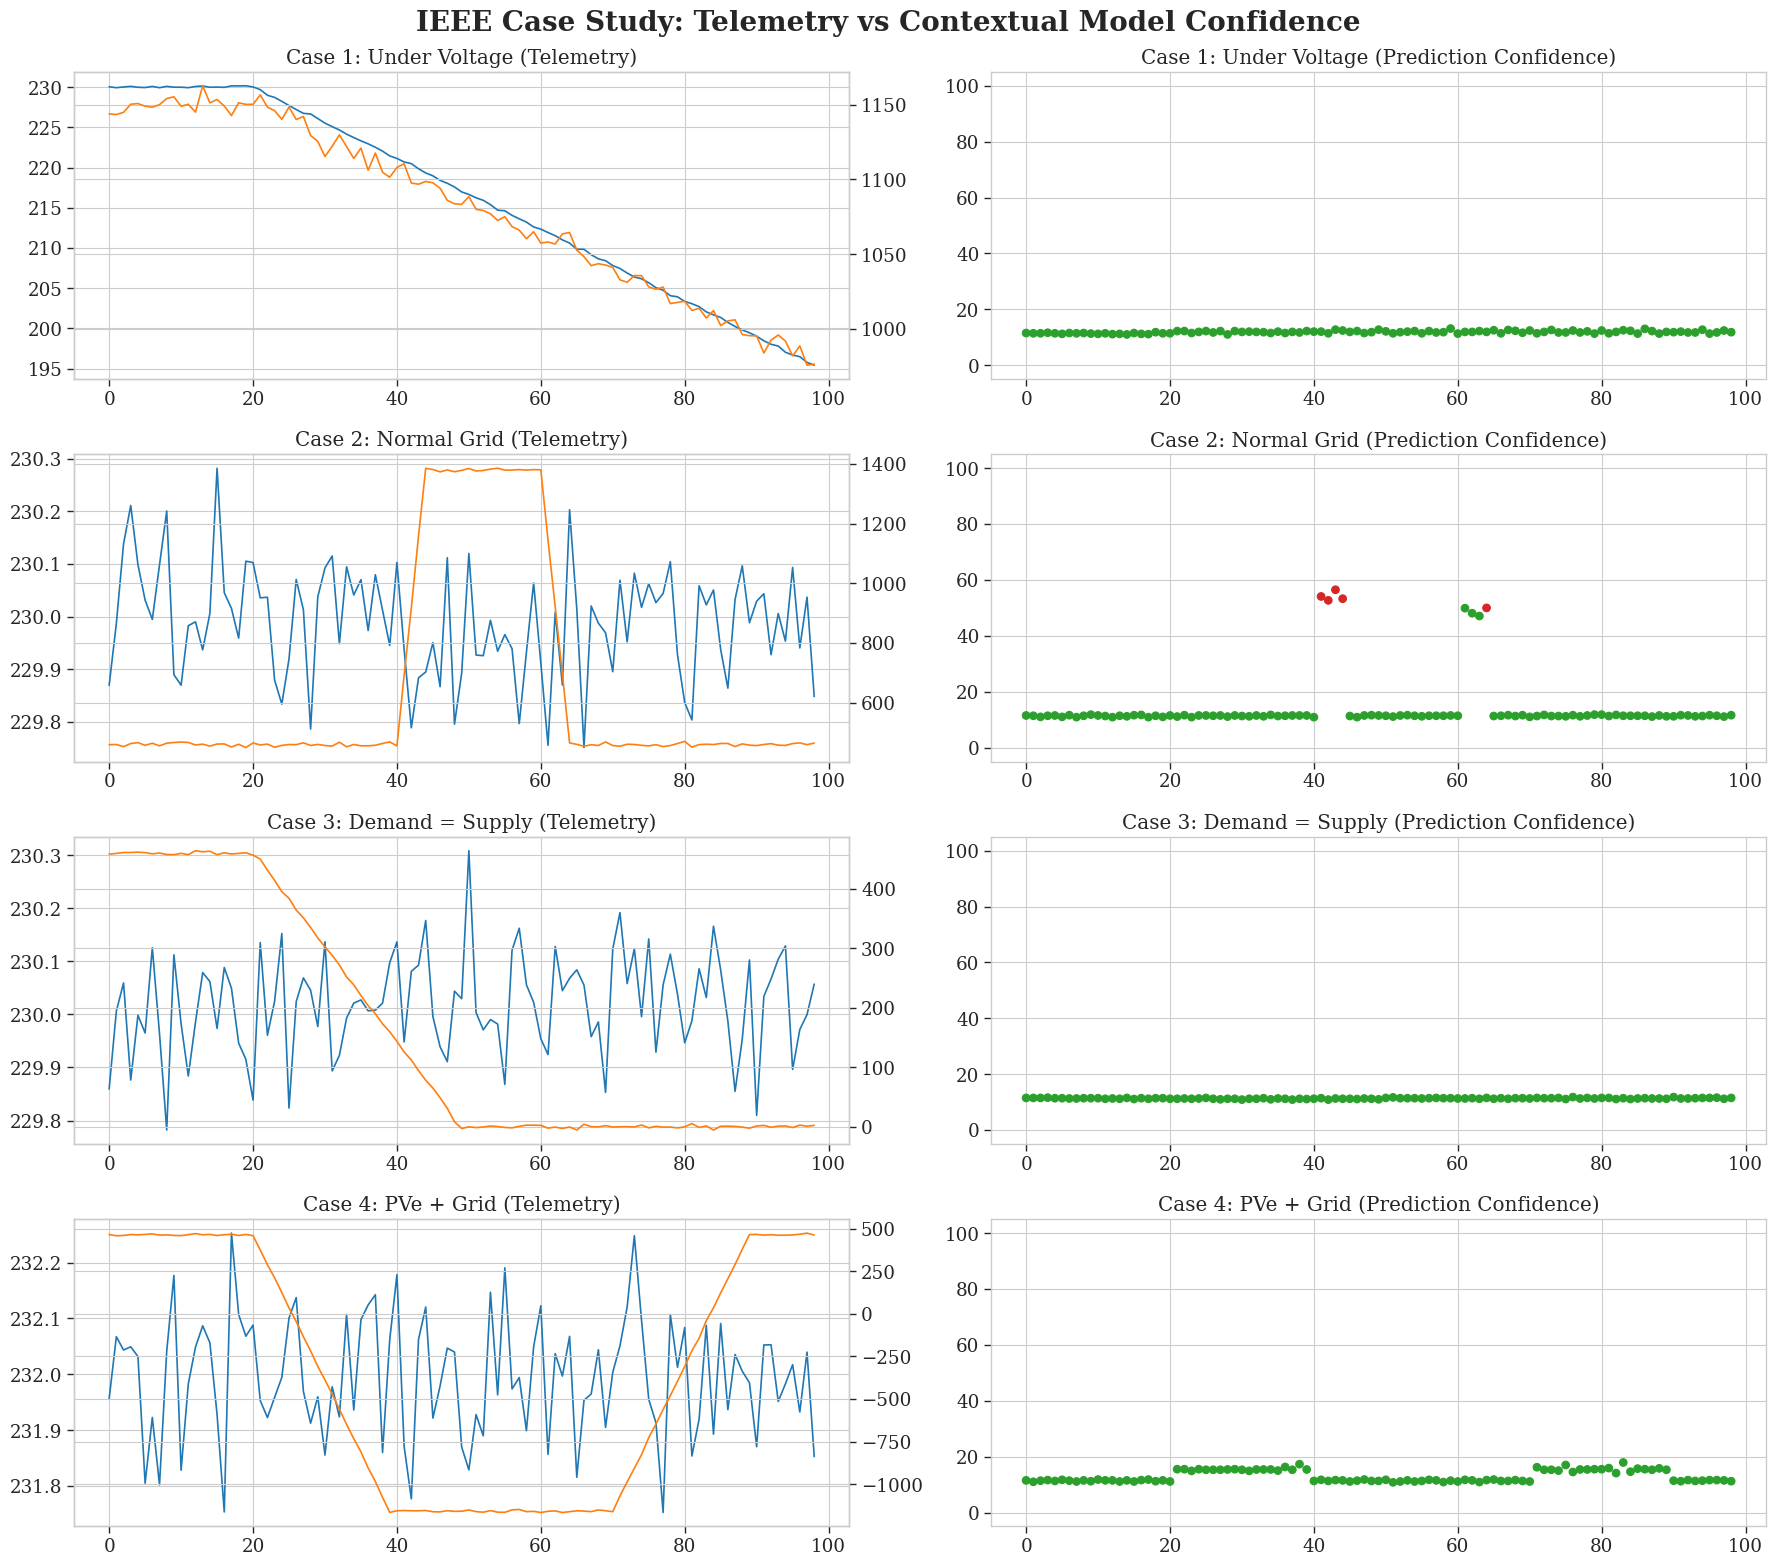

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(18, 16))
fig.suptitle('IEEE Case Study: Telemetry vs Contextual Model Confidence', fontsize=20, fontweight='bold', y=0.98)

for idx, (case_name, data) in enumerate(cases_data.items()):
    time_axis = np.arange(len(data['results']['pred_anomaly']))
    ax1 = axes[idx, 0]
    ax1.plot(time_axis, data['v'][:-1], color='tab:blue', label='Voltage')
    ax1.set_title(f"{case_name} (Telemetry)")
    ax2 = ax1.twinx()
    ax2.plot(time_axis, data['p'][:-1], color='tab:orange', label='Power')
    
    ax3 = axes[idx, 1]
    conf = data['results']['confidence']
    anom = data['results']['pred_anomaly']
    colors = ['tab:red' if a else 'tab:green' for a in anom]
    ax3.scatter(time_axis, conf, c=colors, s=30)
    ax3.set_title(f"{case_name} (Prediction Confidence)")
    ax3.set_ylim(-5, 105)

plt.tight_layout()
plt.savefig('IEEE_Case_Studies_Results.png', dpi=300)
plt.show()

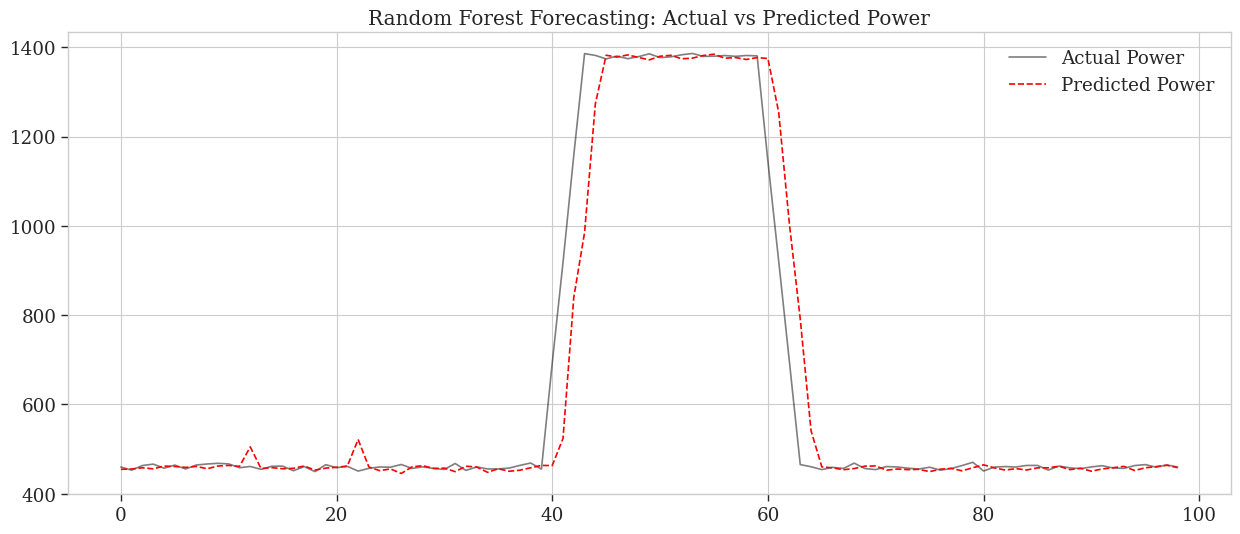

In [ ]:
plt.figure(figsize=(15, 6))
res = cases_data['Case 2: Normal Grid']['results']
plt.plot(res['actual_next_p'], label='Actual Power', color='black', alpha=0.5)
plt.plot(res['pred_next_p'], label='Predicted Power', color='red', linestyle='--')
plt.title("Random Forest Forecasting: Actual vs Predicted Power")
plt.legend()
plt.savefig('RF_Forecasting_Performance.png', dpi=300)
plt.show()